In [17]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [368]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()
ble.reload_config()

2026-04-08 07:12:53,608 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-04-08 07:12:53,609 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-04-08 07:13:03,655 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-04-08 07:13:03,656 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-04-08 07:13:04,654 | INFO     |: Connected to c0:42:0c:78:b8:49


In [369]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
gyr_z_values = []
# pitch_values = []
roll_values = []
tof_2_values = []
dist_sensor_values = []
# dist_output_values = []
orient_sensor_values = []
orient_output_values = []


def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 10:
        t = float(parts[0][2:])
        l = float(parts[1][5:])
        r = float(parts[2][5:])
        ax = float(parts[3][3:])
        gz = float(parts[4][3:])
        ro = float(parts[5][3:])
        t2 = float(parts[6][3:])
        dv = float(parts[7][3:])
        ov = float(parts[8][3:])
        oo = float(parts[9][3:])

        times.append(t) # Convert microseconds to seconds
        left_motors.append(l)
        right_motors.append(r)
        acc_x_values.append(ax)
        gyr_z_values.append(gz)
        roll_values.append(ro)
        tof_2_values.append(t2)
        dist_sensor_values.append(dv)
        orient_sensor_values.append(ov)
        orient_output_values.append(oo)


        print (f"t: {t:.2f}, lm: {l:.2f}, rm: {r:.2f}, gz: {gz:.2f}, t2: {t2:.2f}, dv: {dv:.2f}, ax: {ax:.2f}, ro: {ro:.2f}, ov: {ov:.2f}, oo: {oo:.2f}")
    else:
        print(ble.bytearray_to_string(data))

In [370]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)

In [187]:
ble.send_command(CMD.SEND_LOG, "")

## Flip Mode

In [375]:
ble.send_command(CMD.SET_MODE, "4")
ble.send_command(CMD.SET_DURATION, "5000")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")

ble.send_command(CMD.SET_DIST_SETPOINT, "2000")
ble.send_command(CMD.UPDATE_DIST_PID, "0.05|0.0|0.05")

ble.send_command(CMD.SET_ORIENT_SETPOINT, "0")
ble.send_command(CMD.UPDATE_ORIENT_PID, "1.5|1.2|0.25")

ble.send_command(CMD.SET_DIST_SENSOR_MODE, "2")
ble.send_command(CMD.SET_FLIP_DURATION, "1000000 | 0")

PONG


In [ ]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
gyr_z_values = []
# pitch_values = []
roll_values = []
tof_2_values = []
dist_sensor_values = []
# dist_output_values = []
orient_sensor_values = []
orient_output_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(1)
ble.send_command(CMD.SEND_LOG, "")

t: 5.00, lm: 255.00, rm: 255.00, gz: -0.06, t2: 2953.00, dv: 2953.00, ax: 0.00, ro: -0.20, ov: 0.00, oo: 0.00
t: 7.00, lm: 255.00, rm: 255.00, gz: -0.06, t2: 2953.00, dv: 2953.00, ax: 0.00, ro: -0.20, ov: 0.00, oo: 0.00
t: 8.00, lm: 255.00, rm: 255.00, gz: -0.06, t2: 2953.00, dv: 2953.00, ax: 0.00, ro: -0.20, ov: 0.00, oo: 0.00
t: 16.00, lm: 254.00, rm: 255.00, gz: -0.06, t2: 2953.00, dv: 2953.00, ax: 0.00, ro: -0.29, ov: 0.03, oo: 0.24
t: 27.00, lm: 254.00, rm: 255.00, gz: 8.72, t2: 2953.00, dv: 2953.00, ax: -165.77, ro: -0.29, ov: 0.03, oo: 0.20
t: 33.00, lm: 254.00, rm: 255.00, gz: 8.72, t2: 2953.00, dv: 2953.00, ax: -165.77, ro: -0.29, ov: 0.03, oo: 0.17
t: 44.00, lm: 243.00, rm: 255.00, gz: 38.54, t2: 2953.00, dv: 2953.00, ax: 307.62, ro: -0.55, ov: 0.71, oo: 3.79
t: 51.00, lm: 244.00, rm: 255.00, gz: 38.54, t2: 2953.00, dv: 2953.00, ax: 307.62, ro: -0.55, ov: 0.71, oo: 3.25
t: 61.00, lm: 243.00, rm: 255.00, gz: 8.84, t2: 2953.00, dv: 2953.00, ax: 999.51, ro: -0.69, ov: 0.86, oo: 

In [294]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
acc_x_values = np.array(acc_x_values)
gyr_z_values = np.array(gyr_z_values)
roll_values = np.array(roll_values)
tof_2_values = np.array(tof_2_values)
dist_sensor_values = np.array(dist_sensor_values)
orient_sensor_values = np.array(orient_sensor_values)
orient_output_values = np.array(orient_output_values)

In [275]:
idx = np.where(times > 3000)[0][0]
times = times[:idx]
left_motors = left_motors[:idx]
right_motors = right_motors[:idx]
acc_x_values = acc_x_values[:idx]
gyr_z_values = gyr_z_values[:idx]
roll_values = roll_values[:idx]
tof_2_values = tof_2_values[:idx]
dist_sensor_values = dist_sensor_values[:idx]
orient_sensor_values = orient_sensor_values[:idx]
orient_output_values = orient_output_values[:idx]

In [281]:
np.savez("lab8/flip_3.npz",
    times=times,
    left_motors=left_motors,
    right_motors=right_motors,
    acc_x_values=acc_x_values,
    gyr_z_values=gyr_z_values,
    roll_values=roll_values,
    tof_2_values=tof_2_values,
    dist_sensor_values=dist_sensor_values,
    orient_sensor_values=orient_sensor_values,
    orient_output_values=orient_output_values
)

In [364]:
data = np.load("lab8/flip_3.npz")
times = data['times']
left_motors = data['left_motors']
right_motors = data['right_motors']
acc_x_values = data['acc_x_values']
gyr_z_values = data['gyr_z_values']
roll_values = data['roll_values']
tof_2_values = data['tof_2_values']
dist_sensor_values = data['dist_sensor_values']
orient_sensor_values = data['orient_sensor_values']
orient_output_values = data['orient_output_values']

In [365]:
idx = np.where(times > 4000)[0][0]
times = times[:idx]
left_motors = left_motors[:idx]
right_motors = right_motors[:idx]
acc_x_values = acc_x_values[:idx]
gyr_z_values = gyr_z_values[:idx]
roll_values = roll_values[:idx]
tof_2_values = tof_2_values[:idx]
dist_sensor_values = dist_sensor_values[:idx]
orient_sensor_values = orient_sensor_values[:idx]
orient_output_values = orient_output_values[:idx]

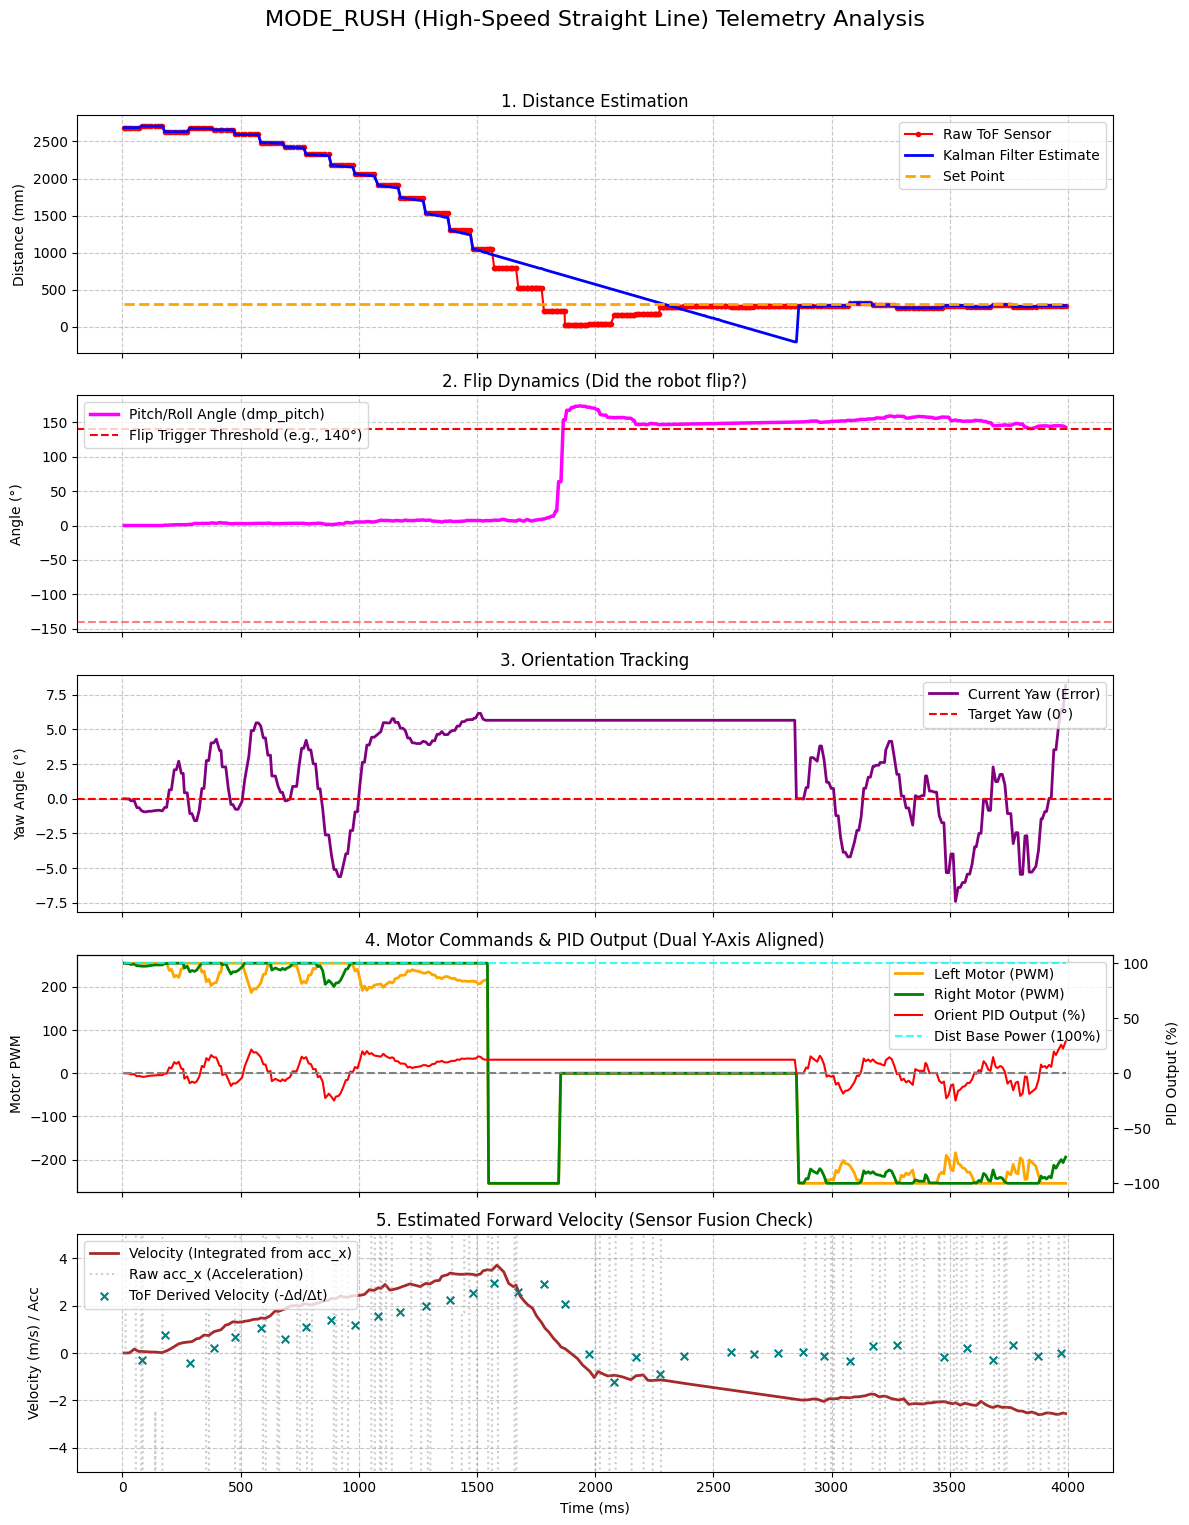

In [367]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ==========================================
# 数据预处理 (Data Pre-processing)
# ==========================================
time_axis = times 

# 1. 计算推算速度 (Velocity derived from Acceleration)
# 假设 times 的单位是毫秒 (ms), 将其转为秒计算 dt
velocity_values = np.zeros_like(acc_x_values, dtype=float)

# 根据你 IMU 库的单位，可能需要将 acc_x 转换为 m/s^2 
# 如果 acc_x 是 mg (毫重力加速度): ACC_SCALE = 9.81 / 1000.0
# 如果 acc_x 已经是 m/s^2: ACC_SCALE = 1.0
ACC_SCALE = 9.81 / 1000.0 *0.9

for i in range(1, len(times)):
    dt = (times[i] - times[i-1]) / 1000.0  # ms to seconds
    # 梯形积分 (或者简单欧拉积分) 计算速度
    velocity_values[i] = velocity_values[i-1] + acc_x_values[i] * ACC_SCALE * dt


tof_vel_t = []
tof_vel_v = []
last_tof = tof_2_values[0]
last_t = times[0]

for i in range(1, len(times)):
    # 只有当 ToF 读数真正发生变化时，才计算这之间的时间差和速度
    if tof_2_values[i] != last_tof:
        dt_ms = times[i] - last_t
        if dt_ms > 0:
            # 距离是 mm，时间是 ms。计算结果是 mm/ms，等同于 m/s。
            # 加负号是因为小车靠近墙壁时距离减小，但向前的速度应当是正的
            v_tof = -(tof_2_values[i] - last_tof) / dt_ms
            tof_vel_t.append(times[i])
            tof_vel_v.append(v_tof)
        
        last_tof = tof_2_values[i]
        last_t = times[i]

# ==========================================
# 绘图设置 (Plotting)
# ==========================================
# 创建 5 个子图，共享 X 轴
fig, axs = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
fig.suptitle('MODE_RUSH (High-Speed Straight Line) Telemetry Analysis', fontsize=16)

# --- Subplot 1: 距离与估计 (Distance) ---
axs[0].plot(time_axis, tof_2_values, label='Raw ToF Sensor', color='red', marker='.')
axs[0].plot(time_axis, dist_sensor_values, label='Kalman Filter Estimate', color='blue',alpha=1.0, linewidth=2)
axs[0].plot(time_axis, np.full_like(time_axis, 304.0), label='Set Point', color='orange',linestyle='--',alpha=1.0, linewidth=2)
axs[0].set_ylabel('Distance (mm)')
axs[0].set_title('1. Distance Estimation')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.7)

# --- Subplot 2: 【新增】翻转姿态角 (Flip Dynamics / Roll & Pitch) ---
axs[1].plot(time_axis, roll_values, label='Pitch/Roll Angle (dmp_pitch)', color='magenta', linewidth=2.5)
# 画出你在代码中设定的翻转判定阈值 (假设是 140 度或 160 度)
axs[1].axhline(140, color='red', linestyle='--', label='Flip Trigger Threshold (e.g., 140°)')
axs[1].axhline(-140, color='red', linestyle='--', alpha=0.5)
axs[1].set_ylabel('Angle (°)')
axs[1].set_title('2. Flip Dynamics (Did the robot flip?)')
axs[1].legend(loc='upper left')
axs[1].grid(True, linestyle='--', alpha=0.7)


# --- Subplot 3: 航向角误差 (Orientation / Yaw) ---
axs[2].plot(time_axis, orient_sensor_values, label='Current Yaw (Error)', color='purple', linewidth=2)
axs[2].axhline(0, color='red', linestyle='--', label='Target Yaw (0°)')
axs[2].set_ylabel('Yaw Angle (°)')
axs[2].set_title('3. Orientation Tracking')
axs[2].legend(loc='upper right')
axs[2].grid(True, linestyle='--', alpha=0.7)

# --- Subplot 4: 电机与 PID (双 Y 轴对齐) ---
ax3_pwm = axs[3]
ax3_pct = ax3_pwm.twinx()  # 创建共享 X 轴的右侧 Y 轴

# 绘制左轴数据：PWM (-255 ~ 255)
line1 = ax3_pwm.plot(time_axis, left_motors, label='Left Motor (PWM)', color='orange', linewidth=2)
line2 = ax3_pwm.plot(time_axis, right_motors, label='Right Motor (PWM)', color='green', linewidth=2)

# 绘制右轴数据：PID Percentage (-100% ~ 100%)
line3 = ax3_pct.plot(time_axis, orient_output_values, label='Orient PID Output (%)', color='red', linestyle='-', linewidth=1.5)
# 模拟 dist_output_values = 100% 的基础冲刺油门线
line4 = ax3_pct.plot(time_axis, np.full_like(time_axis, 100.0), label='Dist Base Power (100%)', color='cyan', linestyle='--', alpha=0.8)
line5= ax3_pct.plot(time_axis,np.full_like(time_axis, 0.0),color='gray', linestyle='--')

# **关键：严格对齐两个 Y 轴的比例**
# PWM 轴设为 ±260 留一点边距，Percent 轴按照 100/255 的比例设为 ±101.96
ax3_pwm.set_ylim(-275, 275)
ax3_pct.set_ylim(-275 * (100.0/255.0), 275 * (100.0/255.0)) 

ax3_pwm.set_ylabel('Motor PWM')
ax3_pct.set_ylabel('PID Output (%)')
ax3_pwm.set_title('4. Motor Commands & PID Output (Dual Y-Axis Aligned)')

# 合并双轴的图例 (Legend)
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax3_pwm.legend(lines, labels, loc='upper right')
ax3_pwm.grid(True, linestyle='--', alpha=0.7)

# --- Subplot 5: 推算速度图 (Velocity from IMU) ---
axs[4].plot(time_axis, velocity_values, label='Velocity (Integrated from acc_x)', color='brown', linewidth=2)
axs[4].plot(time_axis, acc_x_values, label='Raw acc_x (Acceleration)', color='gray', alpha=0.4, linestyle=':')

axs[4].scatter(tof_vel_t, tof_vel_v, label='ToF Derived Velocity (-Δd/Δt)', color='teal', marker='x', s=30, zorder=5)
# if len(fit_t) > 0:
#     axs[3].plot(fit_t, fit_v, label='ToF Velocity (Exponential Fit)', color='magenta', linewidth=2.5, linestyle='--', zorder=6)

axs[4].set_ylabel('Velocity (m/s) / Acc')
axs[4].set_xlabel('Time (ms)')
axs[4].set_title('5. Estimated Forward Velocity (Sensor Fusion Check)')
axs[4].legend(loc='upper left')
axs[4].grid(True, linestyle='--', alpha=0.7)
axs[4].set_ylim(-5,5)

# 调整布局并显示
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## Rush Mode

In [118]:
ble.send_command(CMD.SET_MODE, "2")
ble.send_command(CMD.SET_DURATION, "2500")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")

ble.send_command(CMD.SET_DIST_SETPOINT, "304")
ble.send_command(CMD.UPDATE_DIST_PID, "0.05|0.0|0.05")

ble.send_command(CMD.SET_ORIENT_SETPOINT, "0")
ble.send_command(CMD.UPDATE_ORIENT_PID, "1.5|1.2|0.25")

ble.send_command(CMD.SET_DIST_SENSOR_MODE, "2")

PONG


In [119]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
gyr_z_values = []
# pitch_values = []
roll_values = []
tof_2_values = []
dist_sensor_values = []
# dist_output_values = []
orient_sensor_values = []
orient_output_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(6)
ble.send_command(CMD.SEND_LOG, "")

KeyboardInterrupt: 

In [ ]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
acc_x_values = np.array(acc_x_values)
gyr_z_values = np.array(gyr_z_values)
roll_values = np.array(roll_values)
tof_2_values = np.array(tof_2_values)
dist_sensor_values = np.array(dist_sensor_values)
orient_sensor_values = np.array(orient_sensor_values)
orient_output_values = np.array(orient_output_values)

In [ ]:
idx = np.where(times > 2000)[0][0]
times = times[:idx]
left_motors = left_motors[:idx]
right_motors = right_motors[:idx]
acc_x_values = acc_x_values[:idx]
gyr_z_values = gyr_z_values[:idx]
roll_values = roll_values[:idx]
tof_2_values = tof_2_values[:idx]
dist_sensor_values = dist_sensor_values[:idx]
orient_sensor_values = orient_sensor_values[:idx]
orient_output_values = orient_output_values[:idx]

In [78]:
np.savez("lab8/rush_2.5s.npz",
    times=times,
    left_motors=left_motors,
    right_motors=right_motors,
    acc_x_values=acc_x_values,
    gyr_z_values=gyr_z_values,
    roll_values=roll_values,
    tof_2_values=tof_2_values,
    dist_sensor_values=dist_sensor_values,
    orient_sensor_values=orient_sensor_values,
    orient_output_values=orient_output_values
)

拟合完成: 预测稳态极速 V_max = 32045.31 m/s, 时间常数 Tau = 19429205.00 ms


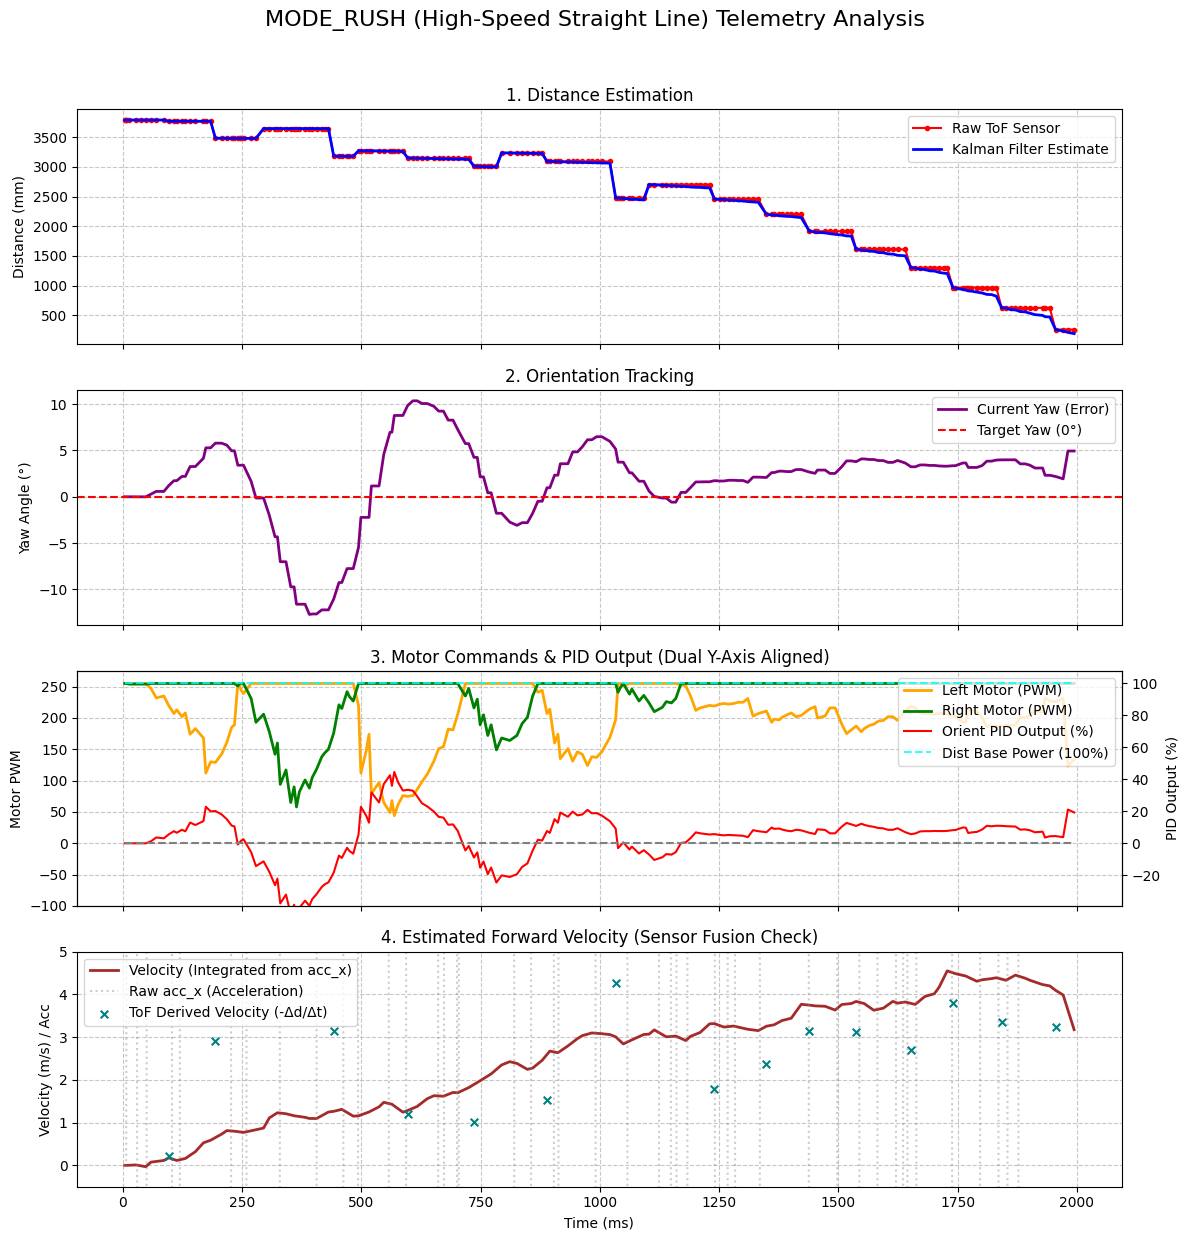

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ==========================================
# 数据预处理 (Data Pre-processing)
# ==========================================
time_axis = times 

# 1. 计算推算速度 (Velocity derived from Acceleration)
# 假设 times 的单位是毫秒 (ms), 将其转为秒计算 dt
velocity_values = np.zeros_like(acc_x_values, dtype=float)

# 根据你 IMU 库的单位，可能需要将 acc_x 转换为 m/s^2 
# 如果 acc_x 是 mg (毫重力加速度): ACC_SCALE = 9.81 / 1000.0
# 如果 acc_x 已经是 m/s^2: ACC_SCALE = 1.0
ACC_SCALE = 9.81 / 1000.0 *0.9

for i in range(1, len(times)):
    dt = (times[i] - times[i-1]) / 1000.0  # ms to seconds
    # 梯形积分 (或者简单欧拉积分) 计算速度
    velocity_values[i] = velocity_values[i-1] + acc_x_values[i] * ACC_SCALE * dt


tof_vel_t = []
tof_vel_v = []
last_tof = tof_2_values[0]
last_t = times[0]

for i in range(1, len(times)):
    # 只有当 ToF 读数真正发生变化时，才计算这之间的时间差和速度
    if tof_2_values[i] != last_tof:
        dt_ms = times[i] - last_t
        if dt_ms > 0:
            # 距离是 mm，时间是 ms。计算结果是 mm/ms，等同于 m/s。
            # 加负号是因为小车靠近墙壁时距离减小，但向前的速度应当是正的
            v_tof = -(tof_2_values[i] - last_tof) / dt_ms
            tof_vel_t.append(times[i])
            tof_vel_v.append(v_tof)
        
        last_tof = tof_2_values[i]
        last_t = times[i]

def velocity_model(t, v_max, tau):
    t_shifted = t - tof_vel_t[0] 
    return v_max * (1 - np.exp(-t_shifted / tau))

if len(tof_vel_t) > 3:
    t_array = np.array(tof_vel_t)
    v_array = np.array(tof_vel_v)
    initial_guess = [4.0, 500.0]
    
    try:
        # 进行曲线拟合
        popt, pcov = curve_fit(velocity_model, t_array, v_array, p0=initial_guess)
        v_max_fit, tau_fit = popt
        
        # 打印出拟合得到的物理参数，这对你了解小车性能非常有用！
        print(f"拟合完成: 预测稳态极速 V_max = {v_max_fit:.2f} m/s, 时间常数 Tau = {tau_fit:.2f} ms")
        
        # 生成平滑的时间 X 轴用于画拟合曲线
        fit_t = np.linspace(min(t_array), max(t_array), 200)
        fit_v = velocity_model(fit_t, v_max_fit, tau_fit)
    except RuntimeError:
        print("拟合失败，数据点可能过于分散。")
        fit_t, fit_v = [], []
else:
    fit_t, fit_v = [], []
# ==========================================
# 绘图设置 (Plotting)
# ==========================================
# 创建 4 个子图，共享 X 轴
fig, axs = plt.subplots(4, 1, figsize=(12, 13), sharex=True)
fig.suptitle('MODE_RUSH (High-Speed Straight Line) Telemetry Analysis', fontsize=16)

# --- Subplot 1: 距离与估计 (Distance) ---
axs[0].plot(time_axis, tof_2_values, label='Raw ToF Sensor', color='red', marker='.')
axs[0].plot(time_axis, dist_sensor_values, label='Kalman Filter Estimate', color='blue',alpha=1.0, linewidth=2)
axs[0].set_ylabel('Distance (mm)')
axs[0].set_title('1. Distance Estimation')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.7)

# --- Subplot 2: 航向角误差 (Orientation / Yaw) ---
axs[1].plot(time_axis, orient_sensor_values, label='Current Yaw (Error)', color='purple', linewidth=2)
axs[1].axhline(0, color='red', linestyle='--', label='Target Yaw (0°)')
axs[1].set_ylabel('Yaw Angle (°)')
axs[1].set_title('2. Orientation Tracking')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.7)

# --- Subplot 3: 电机与 PID (双 Y 轴对齐) ---
ax3_pwm = axs[2]
ax3_pct = ax3_pwm.twinx()  # 创建共享 X 轴的右侧 Y 轴

# 绘制左轴数据：PWM (-255 ~ 255)
line1 = ax3_pwm.plot(time_axis, left_motors, label='Left Motor (PWM)', color='orange', linewidth=2)
line2 = ax3_pwm.plot(time_axis, right_motors, label='Right Motor (PWM)', color='green', linewidth=2)

# 绘制右轴数据：PID Percentage (-100% ~ 100%)
line3 = ax3_pct.plot(time_axis, orient_output_values, label='Orient PID Output (%)', color='red', linestyle='-', linewidth=1.5)
# 模拟 dist_output_values = 100% 的基础冲刺油门线
line4 = ax3_pct.plot(time_axis, np.full_like(time_axis, 100.0), label='Dist Base Power (100%)', color='cyan', linestyle='--', alpha=0.8)
line5= ax3_pct.plot(time_axis,np.full_like(time_axis, 0.0),color='gray', linestyle='--')

# **关键：严格对齐两个 Y 轴的比例**
# PWM 轴设为 ±260 留一点边距，Percent 轴按照 100/255 的比例设为 ±101.96
ax3_pwm.set_ylim(-100, 275)
ax3_pct.set_ylim(-100 * (100.0/255.0), 275 * (100.0/255.0)) 

ax3_pwm.set_ylabel('Motor PWM')
ax3_pct.set_ylabel('PID Output (%)')
ax3_pwm.set_title('3. Motor Commands & PID Output (Dual Y-Axis Aligned)')

# 合并双轴的图例 (Legend)
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax3_pwm.legend(lines, labels, loc='upper right')
ax3_pwm.grid(True, linestyle='--', alpha=0.7)

# --- Subplot 4: 推算速度图 (Velocity from IMU) ---
axs[3].plot(time_axis, velocity_values, label='Velocity (Integrated from acc_x)', color='brown', linewidth=2)
axs[3].plot(time_axis, acc_x_values, label='Raw acc_x (Acceleration)', color='gray', alpha=0.4, linestyle=':')

axs[3].scatter(tof_vel_t, tof_vel_v, label='ToF Derived Velocity (-Δd/Δt)', color='teal', marker='x', s=30, zorder=5)
# if len(fit_t) > 0:
#     axs[3].plot(fit_t, fit_v, label='ToF Velocity (Exponential Fit)', color='magenta', linewidth=2.5, linestyle='--', zorder=6)

axs[3].set_ylabel('Velocity (m/s) / Acc')
axs[3].set_xlabel('Time (ms)')
axs[3].set_title('4. Estimated Forward Velocity (Sensor Fusion Check)')
axs[3].legend(loc='upper left')
axs[3].grid(True, linestyle='--', alpha=0.7)
axs[3].set_ylim(-0.5,5)

# 调整布局并显示
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()